In [ ]:
from dotenv import load_dotenv
load_dotenv()

from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from pydantic import 

from langchain_mistralai import ChatMistralAI






In [ ]:
model = ChatMistralAI(
    model = "mistral-small-latest"
)

In [ ]:
model.invoke("Hello")

AIMessage(content='Hello! 😊 How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'prompt_tokens': 16, 'total_tokens': 29, 'completion_tokens': 13, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-small-latest', 'model': 'mistral-small-latest', 'finish_reason': 'stop', 'model_provider': 'mistralai'}, id='lc_run--019d05f0-fc6a-7851-b6ac-04af8e631d6a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 13, 'total_tokens': 29})

In [10]:
class BatsmanState(TypedDict):
    runs: int
    balls: int 
    fours: int 
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str

    
    

In [55]:
def calculate_sr(state: BatsmanState)-> BatsmanState:
    sr = (state['runs'] / state['balls']) * 100
    state['sr'] = sr

    return {
        "sr": sr
    }


In [56]:
def calculate_bpb(state: BatsmanState)-> BatsmanState:
    bpb = (state['balls'] / (state['fours'] + state['sixes']))
    state['bpb'] = bpb

    return {
        "bpb":bpb
    }


In [57]:
def calculate_boundary_percent(state: BatsmanState)-> BatsmanState:
    bp = (state['fours'] * 4 + state['sixes'] * 6)  * 100
    state['boundary_percent'] = bp

    return {
        "boundary_percent":bp
    }


In [58]:
def summary(state: BatsmanState)-> BatsmanState:
    summary = f"""
Strike Rate - {state['sr']}
Balls per boundary - {state['bpb']}
Boundary percent- {state["boundary_percent"]}
"""
    state['summary'] = summary

    return {
        "summary":summary
    }


In [59]:
# define the graph with state 
graph = StateGraph(state_schema=BatsmanState)

In [60]:
#add nodes to the graph 
graph.add_node(
    "calculate_sr",
    calculate_sr
)
graph.add_node(
    "calculate_bpb",
    calculate_bpb
)
graph.add_node(
    "calculate_boundary_percent",
    calculate_boundary_percent
)
graph.add_node(
    "summary",
    summary
)

In [61]:
# add edges to the graph 
graph.add_edge(START,"calculate_sr")
graph.add_edge(START,"calculate_bpb")
graph.add_edge(START,"calculate_boundary_percent")
graph.add_edge("calculate_sr","summary")
graph.add_edge("calculate_bpb","summary")
graph.add_edge("calculate_boundary_percent","summary")
graph.add_edge("summary",END)


In [62]:
# compile the graph 
workflow = graph.compile()


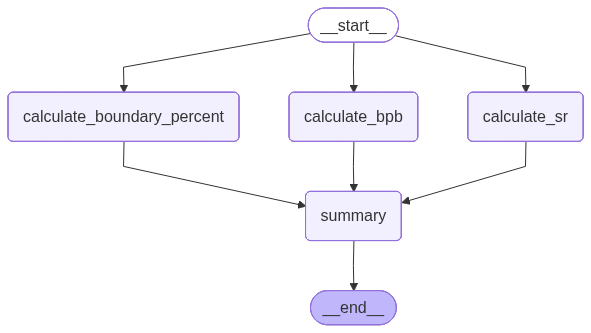

In [63]:
workflow

In [64]:
# making initial state for triggering the workflow 
initial_state = {
    "runs": 100,
    "balls": 50,
    "fours": 6,
    "sixes": 4,
}

In [65]:
#execute the graph 
final_state = workflow.invoke(initial_state)

In [66]:
final_state

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 4800,
 'summary': '\nStrike Rate - 200.0\nBalls per boundary - 5.0\nBoundary percent- 4800\n'}

In [67]:
print(final_state["summary"])


Strike Rate - 200.0
Balls per boundary - 5.0
Boundary percent- 4800



# **The Indian Ocean: A Vast Maritime Realm of Trade, Culture, and Life**

### *By [Your Name]*

---

## **Introduction**

*"Stretching from the east coast of Africa to the shores of Australia, the Indian Ocean is the third-largest ocean in the world—but its significance goes far beyond its size."*

For millennia, this vast expanse of blue has been more than just water—it has been a highway of civilizations, a battleground for empires, a cradle of biodiversity, and a stage for geopolitical maneuvering. Home to over **2,000 species of fish**, some of the world’s most critical trade routes, and the remnants of ancient maritime cultures, the Indian Ocean remains one of the most dynamic and strategically vital regions on Earth.

From the **spice trade that connected Rome to Indonesia** to the modern-day **China-led "String of Pearls" strategy**, the Indian Ocean has shaped economies, religions, and ecosystems for thousands of years. Yet, today, it faces unprecedented threats—**climate chan